# 03 — Data Processing

Pipeline: `venues_raw.csv` → cluster-dedupe → enrich jam buka & metrik
sintetis → `venues_enriched.csv`.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

## Masalah yang ditangani di tahap ini

1. **Boundary mismatch** — bbox persegi awal overlap sebagian Bekasi/Depok/
   Tangerang. Fix: filter pakai area administratif asli DKI Jakarta.
2. **Duplikat entitas** — venue besar (cth Monas) punya >1 elemen OSM
   (gerbang utara/selatan/timur/barat + taman + monumen) yang sebenarnya
   1 destinasi. Fix: `dedupe_clusters()` cluster transitif by jarak+nama.
3. **Jam buka** — sebagian venue OSM tidak punya tag `opening_hours`,
   pakai default per kategori (ditandai `hours_source=default`).

## Jalankan enrich

Uncomment untuk re-run (baca venues_raw.csv, butuh ~10 detik).

In [2]:
# import enrich
# enrich.main()

## Sebelum vs sesudah cluster-dedupe (studi kasus Monas)

In [3]:
raw = pd.read_csv("../../data/venues_raw.csv")
monas = raw[raw["name"].str.contains("monas|monumen nasional", case=False, na=False, regex=True)]
monas[["venue_id", "name", "venue_category", "latitude", "longitude"]]

,venue_id,name,venue_category,latitude,longitude
183,way/628537709,Taman Monas,tourism:yes,-6.175857,106.827019
607,way/1159084257,Monumen Nasional,tourism:yes,-6.175407,106.827167


Setelah `collect.py` (cluster-dedupe sudah berjalan di tahap collection):
4 gerbang Monas + taman tergabung jadi 1 row, monumen tetap terpisah
(entitas konsep berbeda).

## Hasil akhir: data/venues_enriched.csv

In [4]:
df = pd.read_csv("../../data/venues_enriched.csv")
print(f"Total venue: {len(df)}")
print(f"Kolom: {len(df.columns)}")
df.head()

Total venue: 6166
Kolom: 25


,venue_id,name,venue_category,latitude,longitude,unique_visitors,Senin_buka,Senin_tutup,Selasa_buka,Selasa_tutup,...,Jumat_tutup,Sabtu_buka,Sabtu_tutup,Minggu_buka,Minggu_tutup,References,time_spent,hours_source,osm_url,maps_url
0,way/28845528,Taman Impian Jaya Ancol,tourism:theme_park,-6.121603,106.845283,3365,09:00,18:00,09:00,18:00,...,18:00,09:00,18:00,09:00,18:00,https://www.ancol.com/,258.9,default,https://www.openstreetmap.org/way/28845528,https://www.google.com/maps/search/?api=1&quer...
1,node/316613327,Art & Craft Market,tourism:attraction,-6.126570,106.839134,630,Tutup,Tutup,09:00,16:00,...,16:00,09:00,16:00,09:00,16:00,https://www.google.com/maps/search/?api=1&quer...,89.2,default,https://www.openstreetmap.org/node/316613327,https://www.google.com/maps/search/?api=1&quer...
2,node/359852056,Wayang Museum,tourism:museum,-6.134815,106.812509,1253,Tutup,Tutup,09:00,16:30,...,16:30,09:00,16:30,09:00,16:30,https://en.wikipedia.org/wiki/Wayang_Museum,105.4,osm,https://www.openstreetmap.org/node/359852056,https://www.google.com/maps/search/?api=1&quer...
3,node/1699892511,Rizel Art,tourism:artwork,-5.738238,106.601025,5525,Tutup,Tutup,09:00,16:00,...,16:00,09:00,16:00,09:00,16:00,https://www.google.com/maps/search/?api=1&quer...,213.8,default,https://www.openstreetmap.org/node/1699892511,https://www.google.com/maps/search/?api=1&quer...
4,node/1699892548,Tas dari Daur Ulang Sampah,tourism:artwork,-5.738389,106.600869,2342,Tutup,Tutup,09:00,16:00,...,16:00,09:00,16:00,09:00,16:00,https://www.google.com/maps/search/?api=1&quer...,252.6,default,https://www.openstreetmap.org/node/1699892548,https://www.google.com/maps/search/?api=1&quer...


## Sumber jam buka: OSM nyata vs default kategori

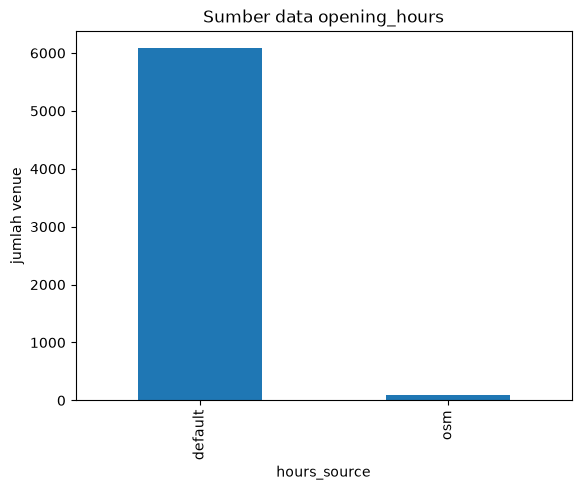

In [5]:
df["hours_source"].value_counts().plot(kind="bar", title="Sumber data opening_hours")
plt.ylabel("jumlah venue")
plt.show()

## Distribusi kategori venue final

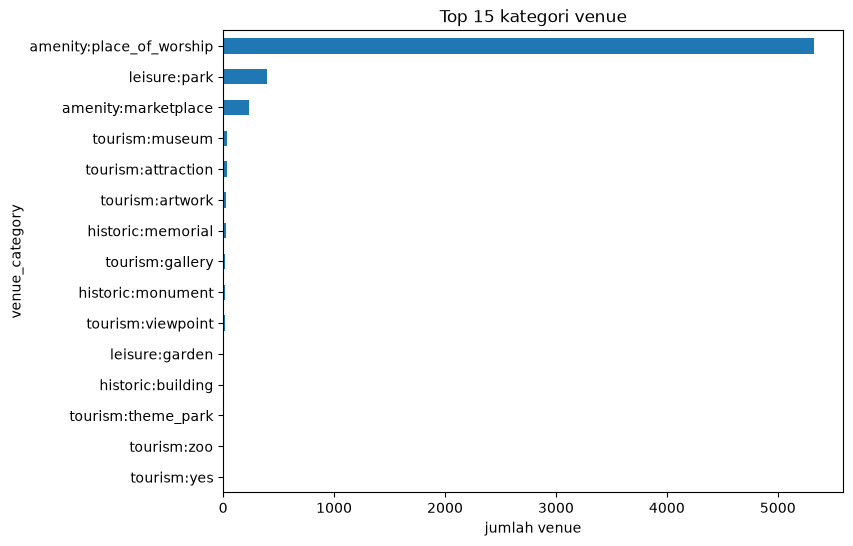

In [6]:
df["venue_category"].value_counts().head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 kategori venue")
plt.xlabel("jumlah venue")
plt.gca().invert_yaxis()
plt.show()

## Distribusi metrik sintetis (unique_visitors, time_spent)

**Catatan limitasi riset**: kedua kolom ini sintetis (model lognormal per
profil kategori), bukan data traffic asli — metrik tersebut privat
platform dan tak tersedia di API publik.

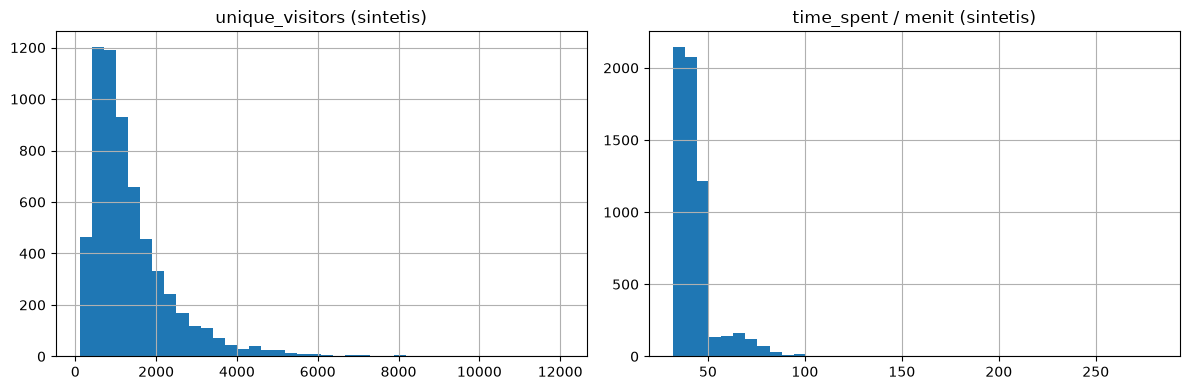

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["unique_visitors"].hist(bins=40, ax=axes[0])
axes[0].set_title("unique_visitors (sintetis)")
df["time_spent"].hist(bins=40, ax=axes[1])
axes[1].set_title("time_spent / menit (sintetis)")
plt.tight_layout()
plt.show()